### GW tutorial 1: Ground-based antenna pattern and redshift horizon

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#### Network antenna patterns

Interferometric detectors are omnidirectional antennas and have a good sensitivity over a large fraction of the sky. The output of the detector will be $h(t)$, which will respond to a passing gravitational wave (GW) as $h_{ij}(t, \textbf{x})$. The general transfer function for GW detectors is

\begin{equation}
\label{eq:outputdetector}
h(t, \textbf{x}) = D^{ij}h_{ij}(t, \textbf{x}),
\end{equation}
where $D_{ij}$ is the detector tensor that depends on its geometry.
For a ground-based detector, we can neglect the spatial dependence of the GW signal $h_{ij}(t, \textbf{x})$, such that

\begin{equation}
h_{ij}(t) = \sum_{A=\text{+}, \times} e^{A}_{ij}(\hat{\textbf{n}}) h_{A}(t).
\end{equation}

The direction of propagation of the wave is $\hat{\textbf{k}}$,  and  $e^{A}_{ij}$ the polarization tensor defined as

\begin{equation}
 e^{A}_{ij}(\hat{\textbf{k}}) =
   \begin{cases}
      \hat{\textbf{u}}_{i}\hat{\textbf{u}}_{j} - \hat{\textbf{v}}_{i}\hat{\textbf{v}}_{j}              & \mbox{for } A=\text{+}   \\
      \hat{\textbf{u}}_{i}\hat{\textbf{v}}_{j} + \hat{\textbf{v}}_{i}\hat{\textbf{u}}_{j}  & \mbox{for } A=\times
   \end{cases}
\end{equation}
where $\hat{\textbf{u}} \text{ and } \hat{\textbf{v}}$ are unit vectors orthogonal to $\hat{\textbf{k}}$. This would be the case when the polarization angle $\psi$ is negligible, so to add this information we can rewrite the polarization tensor as,


\begin{equation}
 e^{rot, A}_{ij}(\hat{\textbf{k}}) =
   \begin{cases}
      \cos{(2\psi)} e^{+}_{ij}(\hat{\textbf{k}}) - \sin{(2\psi)} e^{\times}_{ij}(\hat{\textbf{k}})           & \mbox{for } A=\text{+}   \\
      \sin{(2\psi)} e^{+}_{ij}(\hat{\textbf{k}}) + \cos{(2\psi)} e^{\times}_{ij}(\hat{\textbf{k}})  & \mbox{for } A=\times
   \end{cases}
\end{equation}

**Exercise 1:** create a function called `polarization_tensors` that returns $e_{ij}^{rot, A}(\hat{\textbf{k}})$  in the celestial frame for both polarizations as a function of the wave propagation $\hat{\textbf{k}}$ and the polarization angle $\psi$. Also, create a function called `direction_propagation` that computes $\hat{\textbf{k}}(\theta, \phi) = [\sin{\theta} \cos{\phi}, \sin{\theta} \sin{\phi}, \cos{\theta}]$

_Hint_: Given a unit sphere the unit vector orthogonal to $\hat{\textbf{k}}$ are $e_{\theta} = [\cos{\theta}\cos{\phi}, \cos{\theta}\sin{\phi}, -\sin{\theta}]$ and $e_{\phi} = [- \sin{\phi}, \cos{\phi}, 0]$

In [5]:
def direction_propagation(theta, phi):
  # calculates the direction propagation vector k from formula given:
  direction_k = np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])
  return direction_k

def polarization_tensors(direction_k, psi):
    # decompose direction_k into x,y,z components
    kx, ky, kz = direction_k

    # recover the spherical angles from k_hat
    theta = np.arccos(np.clip(kz, -1.0, 1.0))
    phi   = np.arctan2(ky, kx)

    # calculating orthonormal vectors orthogonal to k
    # u = e_theta, v = e_phi as given from hint
    u = np.array([np.cos(theta) * np.cos(phi),
                  np.cos(theta) * np.sin(phi),
                  -np.sin(theta)])
    v = np.array([-np.sin(phi),
                  np.cos(phi),
                  0.0])

    # base polarization tensors (outer products)
    e_plus  = np.outer(u, u) - np.outer(v, v)   # e^+_{ij} = u_i u_j - v_i v_j
    e_cross = np.outer(u, v) + np.outer(v, u)   # e^x_{ij} = u_i v_j + v_i u_j

    # rotate by the polarization angle psi
    e_plus_rot  = np.cos(2*psi) * e_plus - np.sin(2*psi) * e_cross
    e_cross_rot = np.sin(2*psi) * e_plus + np.cos(2*psi) * e_cross

    #returns two values based on if A = plus or A = cross
    return e_plus_rot, e_cross_rot


Now, we have the polarization tensors taking into account the polarization angle $\psi$. However, this is in celestial coordinates and we need to rotate our vectors according to the local detector frame.

**Exercise 2:** Assuming that a given detector is located at $(\theta_{0}, \phi_{0})$ write a function called rotation matrix.

_Hint_: we need to rotate the z-axis to account for $\theta_0$ and to rotate the x-axis for $\phi_{0}$, so that $R = R_{x}(\pi/2 - \phi_{0}) \cdot R_{z}(\pi /2 +\theta_{0})$

In [6]:
def rotation_matrix(theta_0, phi_0):
  # calculates the rotation matrix R

  # rotate z-axis by (pi/2 + theta_0), x-axis by (pi/2 - phi_0)
  alpha = np.pi/2 + theta_0
  beta  = np.pi/2 - phi_0

  # calculating the Rx, Rz components for dot product
  R_z = np.array([[np.cos(alpha), -np.sin(alpha), 0],
                  [np.sin(alpha), np.cos(alpha), 0],
                  [0, 0, 1]])
  R_x = np.array([[1, 0, 0],
                  [0, np.cos(beta), -np.sin(beta)],
                  [0, np.sin(beta), np.cos(beta)]])

  # dot product as in hint given
  R = np.dot(R_x, R_z)
  return R


So far we have computed the `R = rotation_matrix(theta_0, phi_0)`, the direction of propagation `k = direction_propagation(theta, phi)` and the polarization tensors $e_+$ and $e_{\times}$ with the `polarization_tensors` function. Now, we have all the ingredients to calculate the antenna pattern.


For an L shape detector such as current Advanced LIGO and Advanced Virgo the output of the detector the antenna pattern defined as $F = F_{+}^2 + F_{\times}^{2}$ where

$F_{+}(\theta, \phi, \psi) = \frac{1}{2}[(d_{x}^{T} e_{+}^{local} d_{x})- (d_{y}^{T} e_{+}^{local} d_{y})],$

$F_{\times}(\theta, \phi, \psi) = \frac{1}{2}[(d_{x}^{T} e_{\times}^{local} d_{x})- (d_{y}^{T} e_{\times}^{local} d_{y})].$

Here, $d_{x}$ and $d_{y}$ are the directions of the detector arms in the local frame are defined as:
$
\mathbf{d}_x =
\begin{bmatrix}
\cos\alpha \\
\sin\alpha \\
0
\end{bmatrix},
\quad
\mathbf{d}_y =
\begin{bmatrix}
-\sin\alpha \\
\cos\alpha \\
0
\end{bmatrix}.
$

**Excercise 3:** Create a function called `antenna_pattern(theta, phi, psi, theta_0, phi_0, alpha)`.


_Hint:_ The wave propagation vector $\mathbf{k}$ and polarization tensors $e_+$ and $e_\times$ are transformed to the detector's local frame as follows:

$
\mathbf{k}_\text{local} = R \cdot \mathbf{k}(\theta, \phi),
$

$
e_+^\text{local} = R \cdot e_+ \cdot R^\mathsf{T},
$

$
e_\times^\text{local} = R \cdot e_\times \cdot R^\mathsf{T},
$

where $R^{T}$ denotes the transpose of the rotation matrix \(R\).



In [7]:
def antenna_pattern(theta, phi, psi, theta_0, phi_0, alpha):

  # Get direction of propagation in celestial frame
  k = direction_propagation(theta, phi)

  # Get polarization tensors in celestial frame
  e_plus, e_cross = polarization_tensors(k, psi)

  # Get rotation matrix for detector location
  R = rotation_matrix(theta_0, phi_0)

  # Transform polarization tensors to local frame
  e_plus_local = np.dot(R, np.dot(e_plus, R.T))
  e_cross_local = np.dot(R, np.dot(e_cross, R.T))

  # Define detector arm directions in local frame
  d_x = np.array([np.cos(alpha), np.sin(alpha), 0])
  d_y = np.array([-np.sin(alpha), np.cos(alpha), 0])

  # Calculate F_plus and F_cross
  F_plus = 0.5 * (np.dot(d_x, np.dot(e_plus_local, d_x)) - np.dot(d_y, np.dot(e_plus_local, d_y)))
  F_cross = 0.5 * (np.dot(d_x, np.dot(e_cross_local, d_x)) - np.dot(d_y, np.dot(e_cross_local, d_y)))

  # Calculate the antenna pattern F
  F = np.sqrt(F_plus**2 + F_cross**2)
  return F

Alright, now let's see what this antenna pattern looks like. Below I coded a function to plot it (you are welcome). If everything looks fine it should look like the plot on the slides.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


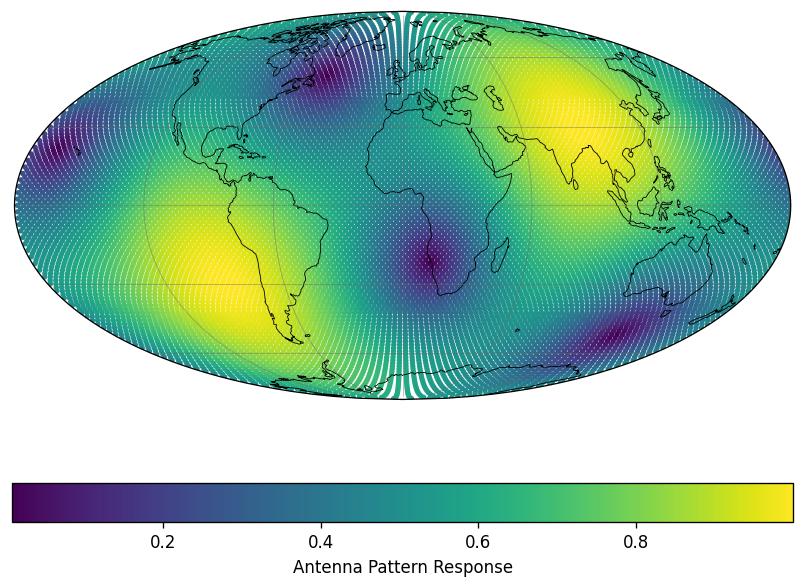

In [8]:
def plot_antenna_pattern(theta_0, phi_0, alpha, psi, nside=32):
    """
    Plot the antenna pattern using Cartopy with Mollweide projection.
    theta_0, phi_0: Detector location (longitude and latitude in radians)
    alpha: Detector orientation (angle of x-arm relative to North in radians)
    psi: Polarization angle
    nside: Resolution parameter for the Healpix map
    """
    npix = hp.nside2npix(nside)
    antenna_map = np.zeros(npix)

    # Compute the antenna pattern
    for pix in range(npix):
        theta, phi = hp.pix2ang(nside, pix)
        antenna_map[pix] = antenna_pattern(theta, phi, psi, theta_0, phi_0, alpha)

    # Healpy's pixel centers for plotting (convert to degrees)
    lon, lat = hp.pix2ang(nside, np.arange(npix), lonlat=True)  # Lon/lat in degrees
    lat = np.radians(lat)  # Convert latitude to radians for Cartopy
    lon = np.radians(lon)  # Convert longitude to radians for Cartopy

    # Create a Mollweide plot using Cartopy
    fig = plt.figure(figsize=(12, 6), dpi=120)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

    # Plot the antenna pattern on Cartopy map
    pc = ax.scatter(lon * 180 / np.pi, lat * 180 / np.pi, c=antenna_map, cmap="viridis", s=5, transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines(color='black', linewidth=0.5)
    ax.set_global()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                      linewidth=0.5, color='dimgrey', alpha=0.5)

    # Add colorbar
    cbar = fig.colorbar(pc, orientation="horizontal", shrink=0.7)
    cbar.set_label("Antenna Pattern Response")
    plt.show()


# Detector location: LIGO Livingston
lat = 30  # Latitude in degrees
lon = -90  # Longitude in degrees
yangle = 160.0  # Y-arm orientation in degrees (clockwise from North)

# Convert to radians for computation
theta_0 = np.radians(lon)
phi_0 = np.radians(lat)
alpha = np.radians(yangle - 90)  # Convert Y-arm to x-arm orientation
psi = 0  # Polarization angle

plot_antenna_pattern(theta_0, phi_0, alpha, psi)


In [ ]:
"The blind spots are located around the south of Africa, south of Green Land and Australia. Additionally, there is a blind spot on the Pacific Ocean"
"The best places to see a gravitational wave is around South America (Chile) and Central Asia (China/India)"

Good job! You are almost at the end of the first part. Now, what can you tell me about the "blind" spots of the detector? Where are they located? Where is the best place to see a gravitational wave?

**Excersice 4:** What about other detectors? Can you remake this plot? See details below:

- _LIGO Hanford:_ lat = 46.45, lon = -119.41, yangle = 171.8

- _Virgo:_ lat = 43.63, lon = 10.5, yangle = 250.0

Good job! You are almost at the end of the first part. Now, what can you tell me about the "blind" spots of the detector? Where are they located? Where is the best place to see a gravitational wave?

**Excersice 4:** What about other detectors? Can you remake this plot? See details below:

- _LIGO Hanford:_ lat = 46.45, lon = -119.41, yangle = 171.8

- _Virgo:_ lat = 43.63, lon = 10.5, yangle = 250.0

Plotting antenna pattern for LIGO Hanford:


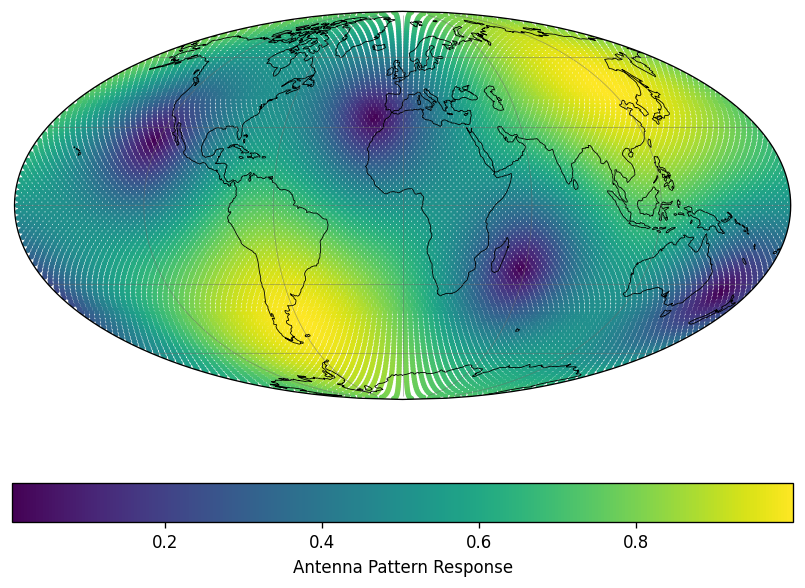


Plotting antenna pattern for Virgo:


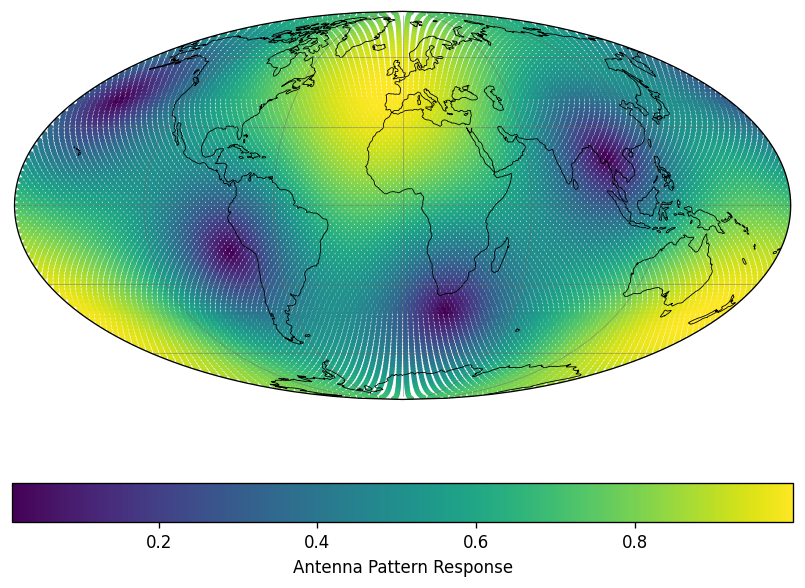

In [9]:
# LIGO Hanford
print("Plotting antenna pattern for LIGO Hanford:")
lat_hanford = 46.45  # Latitude in degrees
lon_hanford = -119.41  # Longitude in degrees
yangle_hanford = 171.8  # Y-arm orientation in degrees (clockwise from North)

theta_0_hanford = np.radians(lon_hanford)
phi_0_hanford = np.radians(lat_hanford)
alpha_hanford = np.radians(yangle_hanford - 90)
psi_hanford = 0

plot_antenna_pattern(theta_0_hanford, phi_0_hanford, alpha_hanford, psi_hanford)

# Virgo
print("\nPlotting antenna pattern for Virgo:")
lat_virgo = 43.63  # Latitude in degrees
lon_virgo = 10.5  # Longitude in degrees
yangle_virgo = 250.0  # Y-arm orientation in degrees (clockwise from North)

theta_0_virgo = np.radians(lon_virgo)
phi_0_virgo = np.radians(lat_virgo)
alpha_virgo = np.radians(yangle_virgo - 90)
psi_virgo = 0

plot_antenna_pattern(theta_0_virgo, phi_0_virgo, alpha_virgo, psi_virgo)

Do you want a curiosity about the detection of the first binary neutron star? [Here](https://dcc.ligo.org/public/0146/G1701985/001/bayestar_no_virgo.png) is the sky map. Where is it located? What can Virgo see? Is it a good thing or a bad thing?

In [8]:
'''

The source is near one of Virgo's blind spots (South America), so Virgo registered almost nothing.
This, counterintuitively, helped as near-non-detection in a working instrument is only consistent
with the source sitting in that detector's insensitive region, which reduced the LIGO-only sky area
dramatically and enabled the optical follow-up that found the first binary neutron star.

'''